In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import os
import re
import glob
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [33]:
# Get all sleep CSV files from Google Drive
file_pattern = "/content/drive/MyDrive/Sleep-*.csv"
files = sorted(glob.glob(file_pattern))

print("Files found:", len(files))
print(files[:5])

rows = []

for file_path in files:
    temp = pd.read_csv(file_path, header=None)
    temp = temp.dropna(how="all")

    row = {}

    for _, r in temp.iterrows():
        if len(r) < 2:
            continue

        key = str(r.iloc[0]).strip() if pd.notna(r.iloc[0]) else None
        value = r.iloc[1] if pd.notna(r.iloc[1]) else np.nan

        if key and key.lower() != "nan":
            row[key] = value

    # Keep filename
    row["Source File"] = os.path.basename(file_path)

    rows.append(row)

data = pd.DataFrame(rows)

print("Raw transformed shape:", data.shape)
data.head()

Files found: 30
['/content/drive/MyDrive/Sleep-1.csv', '/content/drive/MyDrive/Sleep-10.csv', '/content/drive/MyDrive/Sleep-11.csv', '/content/drive/MyDrive/Sleep-12.csv', '/content/drive/MyDrive/Sleep-13.csv']
Raw transformed shape: (30, 20)


,Sleep Score 1 Day,Date,Sleep Duration,Sleep Score,Quality,Sleep Score Factors,Stress Avg,Deep Sleep Duration,Light Sleep Duration,REM Duration,Awake Time,Sleep Timeline Metrics,Restless Moments,Avg Overnight Heart Rate,Resting Heart Rate,Body Battery Change,Avg Respiration,Avg Overnight HRV,7d Avg HRV,Source File
0,NaN,11/30/25,6h 22m,48,Poor,NaN,20.68000031,50m,4h 00m,1h 10m,22m,NaN,35,57,52,34,16.9,56,50,Sleep-1.csv
1,NaN,12/9/25,17m,38,Poor,NaN,24.5,25m,3h 25m,1h 00m,20m,NaN,52,61,58,18,18.19,36,42,Sleep-10.csv
2,NaN,12/10/25,4h 14m,33,Poor,NaN,26.8,20m,2h 40m,1h 00m,14m,NaN,16,63,59,15,22.1,34,40,Sleep-11.csv
3,NaN,12/11/25,6h 34m,57,Fair,NaN,19.29000092,55m,3h 59m,1h 25m,16m,NaN,37,55,52,39,16.4,53,51,Sleep-12.csv
4,NaN,12/12/25,5h 22m,54,Fair,NaN,19.89999962,45m,3h 35m,1h 20m,15m,NaN,32,56,53,34,16.3,49,50,Sleep-13.csv


In [34]:
# Clean messy column names
data.columns = [str(c).strip() for c in data.columns]

# Remove duplicate columns if any
data = data.loc[:, ~data.columns.duplicated()]

print("Columns:")
print(list(data.columns))

Columns:
['Sleep Score 1 Day', 'Date', 'Sleep Duration', 'Sleep Score', 'Quality', 'Sleep Score Factors', 'Stress Avg', 'Deep Sleep Duration', 'Light Sleep Duration', 'REM Duration', 'Awake Time', 'Sleep Timeline Metrics', 'Restless Moments', 'Avg Overnight Heart Rate', 'Resting Heart Rate', 'Body Battery Change', 'Avg Respiration', 'Avg Overnight HRV', '7d Avg HRV', 'Source File']


In [35]:
# Drop fully empty columns
data = data.dropna(axis=1, how="all")

# Drop columns that are basically junk if they exist
junk_cols = ["NaN", "", "B"]
data = data.drop(columns=[c for c in junk_cols if c in data.columns], errors="ignore")

print("Shape after dropping empty/junk columns:", data.shape)
data.head()

Shape after dropping empty/junk columns: (30, 17)


,Date,Sleep Duration,Sleep Score,Quality,Stress Avg,Deep Sleep Duration,Light Sleep Duration,REM Duration,Awake Time,Restless Moments,Avg Overnight Heart Rate,Resting Heart Rate,Body Battery Change,Avg Respiration,Avg Overnight HRV,7d Avg HRV,Source File
0,11/30/25,6h 22m,48,Poor,20.68000031,50m,4h 00m,1h 10m,22m,35,57,52,34,16.9,56,50,Sleep-1.csv
1,12/9/25,17m,38,Poor,24.5,25m,3h 25m,1h 00m,20m,52,61,58,18,18.19,36,42,Sleep-10.csv
2,12/10/25,4h 14m,33,Poor,26.8,20m,2h 40m,1h 00m,14m,16,63,59,15,22.1,34,40,Sleep-11.csv
3,12/11/25,6h 34m,57,Fair,19.29000092,55m,3h 59m,1h 25m,16m,37,55,52,39,16.4,53,51,Sleep-12.csv
4,12/12/25,5h 22m,54,Fair,19.89999962,45m,3h 35m,1h 20m,15m,32,56,53,34,16.3,49,50,Sleep-13.csv


In [36]:
def duration_to_minutes(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if x in ["nan", "", "none"]:
        return np.nan

    # Match things like 6h 24m, 50m, 1h, 1h 05m
    hours = 0
    minutes = 0

    h_match = re.search(r'(\d+)\s*h', x)
    m_match = re.search(r'(\d+)\s*m', x)

    if h_match:
        hours = int(h_match.group(1))
    if m_match:
        minutes = int(m_match.group(1))

    # If it is already numeric as string
    if not h_match and not m_match:
        try:
            return float(x)
        except:
            return np.nan

    return hours * 60 + minutes


duration_columns = [
    "Sleep Duration",
    "Deep Sleep Duration",
    "Light Sleep Duration",
    "REM Duration",
    "Awake Time",
]

for col in duration_columns:
    if col in data.columns:
        data[col] = data[col].apply(duration_to_minutes)

data.head()

,Date,Sleep Duration,Sleep Score,Quality,Stress Avg,Deep Sleep Duration,Light Sleep Duration,REM Duration,Awake Time,Restless Moments,Avg Overnight Heart Rate,Resting Heart Rate,Body Battery Change,Avg Respiration,Avg Overnight HRV,7d Avg HRV,Source File
0,11/30/25,382,48,Poor,20.68000031,50,240,70,22,35,57,52,34,16.9,56,50,Sleep-1.csv
1,12/9/25,17,38,Poor,24.5,25,205,60,20,52,61,58,18,18.19,36,42,Sleep-10.csv
2,12/10/25,254,33,Poor,26.8,20,160,60,14,16,63,59,15,22.1,34,40,Sleep-11.csv
3,12/11/25,394,57,Fair,19.29000092,55,239,85,16,37,55,52,39,16.4,53,51,Sleep-12.csv
4,12/12/25,322,54,Fair,19.89999962,45,215,80,15,32,56,53,34,16.3,49,50,Sleep-13.csv


In [37]:
quality_map = {
    "poor": 0,
    "fair": 1,
    "good": 2,
    "excellent": 3
}

if "Quality" in data.columns:
    data["Quality"] = data["Quality"].astype(str).str.strip().str.lower().map(quality_map)

data.head()

,Date,Sleep Duration,Sleep Score,Quality,Stress Avg,Deep Sleep Duration,Light Sleep Duration,REM Duration,Awake Time,Restless Moments,Avg Overnight Heart Rate,Resting Heart Rate,Body Battery Change,Avg Respiration,Avg Overnight HRV,7d Avg HRV,Source File
0,11/30/25,382,48,0,20.68000031,50,240,70,22,35,57,52,34,16.9,56,50,Sleep-1.csv
1,12/9/25,17,38,0,24.5,25,205,60,20,52,61,58,18,18.19,36,42,Sleep-10.csv
2,12/10/25,254,33,0,26.8,20,160,60,14,16,63,59,15,22.1,34,40,Sleep-11.csv
3,12/11/25,394,57,1,19.29000092,55,239,85,16,37,55,52,39,16.4,53,51,Sleep-12.csv
4,12/12/25,322,54,1,19.89999962,45,215,80,15,32,56,53,34,16.3,49,50,Sleep-13.csv


In [38]:
possible_numeric_cols = [
    "Sleep Score",
    "Stress Avg",
    "Restless Moments",
    "Avg Overnight Heart Rate",
    "Resting Heart Rate",
]

for col in possible_numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      30 non-null     object 
 1   Sleep Duration            30 non-null     int64  
 2   Sleep Score               30 non-null     int64  
 3   Quality                   30 non-null     int64  
 4   Stress Avg                30 non-null     float64
 5   Deep Sleep Duration       30 non-null     int64  
 6   Light Sleep Duration      30 non-null     int64  
 7   REM Duration              30 non-null     int64  
 8   Awake Time                30 non-null     int64  
 9   Restless Moments          30 non-null     int64  
 10  Avg Overnight Heart Rate  30 non-null     int64  
 11  Resting Heart Rate        30 non-null     int64  
 12  Body Battery Change       30 non-null     object 
 13  Avg Respiration           30 non-null     object 
 14  Avg Overnigh

In [39]:
drop_cols = [
    "Date",
    "Sleep Score 1 Day",
    "Sleep Score Factors",
    "Sleep Timeline Metrics",
    "Source File",
]

data = data.drop(columns=[c for c in drop_cols if c in data.columns], errors="ignore")

print("Shape after dropping non-ML columns:", data.shape)
print(data.columns.tolist())
data.head()

Shape after dropping non-ML columns: (30, 15)
['Sleep Duration', 'Sleep Score', 'Quality', 'Stress Avg', 'Deep Sleep Duration', 'Light Sleep Duration', 'REM Duration', 'Awake Time', 'Restless Moments', 'Avg Overnight Heart Rate', 'Resting Heart Rate', 'Body Battery Change', 'Avg Respiration', 'Avg Overnight HRV', '7d Avg HRV']


,Sleep Duration,Sleep Score,Quality,Stress Avg,Deep Sleep Duration,Light Sleep Duration,REM Duration,Awake Time,Restless Moments,Avg Overnight Heart Rate,Resting Heart Rate,Body Battery Change,Avg Respiration,Avg Overnight HRV,7d Avg HRV
0,382,48,0,20.680000,50,240,70,22,35,57,52,34,16.9,56,50
1,17,38,0,24.500000,25,205,60,20,52,61,58,18,18.19,36,42
2,254,33,0,26.800000,20,160,60,14,16,63,59,15,22.1,34,40
3,394,57,1,19.290001,55,239,85,16,37,55,52,39,16.4,53,51
4,322,54,1,19.900000,45,215,80,15,32,56,53,34,16.3,49,50


In [40]:
# Check missing values first
print(data.isna().sum())

# Fill numeric missing values with median
for col in data.columns:
    if data[col].dtype in ["int64", "float64"]:
        data[col] = data[col].fillna(data[col].median())

print("\nMissing values after fill:")
print(data.isna().sum())

Sleep Duration              0
Sleep Score                 0
Quality                     0
Stress Avg                  0
Deep Sleep Duration         0
Light Sleep Duration        0
REM Duration                0
Awake Time                  0
Restless Moments            0
Avg Overnight Heart Rate    0
Resting Heart Rate          0
Body Battery Change         0
Avg Respiration             0
Avg Overnight HRV           0
7d Avg HRV                  0
dtype: int64

Missing values after fill:
Sleep Duration              0
Sleep Score                 0
Quality                     0
Stress Avg                  0
Deep Sleep Duration         0
Light Sleep Duration        0
REM Duration                0
Awake Time                  0
Restless Moments            0
Avg Overnight Heart Rate    0
Resting Heart Rate          0
Body Battery Change         0
Avg Respiration             0
Avg Overnight HRV           0
7d Avg HRV                  0
dtype: int64


In [41]:
print("Final cleaned shape:", data.shape)
data.info()
data.head()

Final cleaned shape: (30, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sleep Duration            30 non-null     int64  
 1   Sleep Score               30 non-null     int64  
 2   Quality                   30 non-null     int64  
 3   Stress Avg                30 non-null     float64
 4   Deep Sleep Duration       30 non-null     int64  
 5   Light Sleep Duration      30 non-null     int64  
 6   REM Duration              30 non-null     int64  
 7   Awake Time                30 non-null     int64  
 8   Restless Moments          30 non-null     int64  
 9   Avg Overnight Heart Rate  30 non-null     int64  
 10  Resting Heart Rate        30 non-null     int64  
 11  Body Battery Change       30 non-null     object 
 12  Avg Respiration           30 non-null     object 
 13  Avg Overnight HRV         30 non-null

,Sleep Duration,Sleep Score,Quality,Stress Avg,Deep Sleep Duration,Light Sleep Duration,REM Duration,Awake Time,Restless Moments,Avg Overnight Heart Rate,Resting Heart Rate,Body Battery Change,Avg Respiration,Avg Overnight HRV,7d Avg HRV
0,382,48,0,20.680000,50,240,70,22,35,57,52,34,16.9,56,50
1,17,38,0,24.500000,25,205,60,20,52,61,58,18,18.19,36,42
2,254,33,0,26.800000,20,160,60,14,16,63,59,15,22.1,34,40
3,394,57,1,19.290001,55,239,85,16,37,55,52,39,16.4,53,51
4,322,54,1,19.900000,45,215,80,15,32,56,53,34,16.3,49,50


In [42]:
cleaned_path = "/content/drive/MyDrive/cleaned_sleep_data.csv"
data.to_csv(cleaned_path, index=False)
print("Saved cleaned dataset to:", cleaned_path)

Saved cleaned dataset to: /content/drive/MyDrive/cleaned_sleep_data.csv


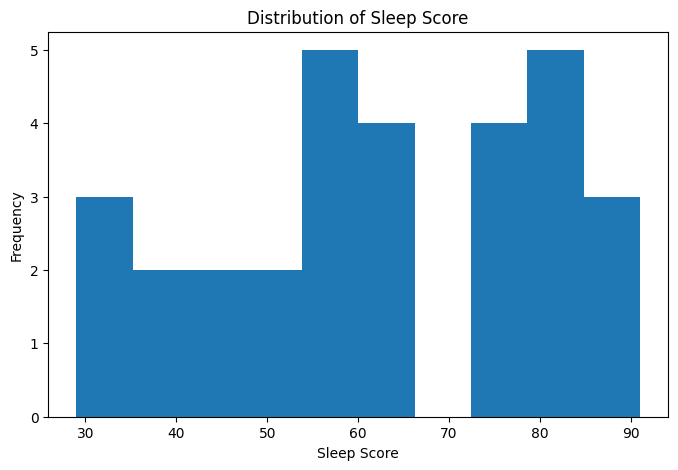

In [43]:
if "Sleep Score" in data.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(data["Sleep Score"].dropna(), bins=10)
    plt.xlabel("Sleep Score")
    plt.ylabel("Frequency")
    plt.title("Distribution of Sleep Score")
    plt.show()

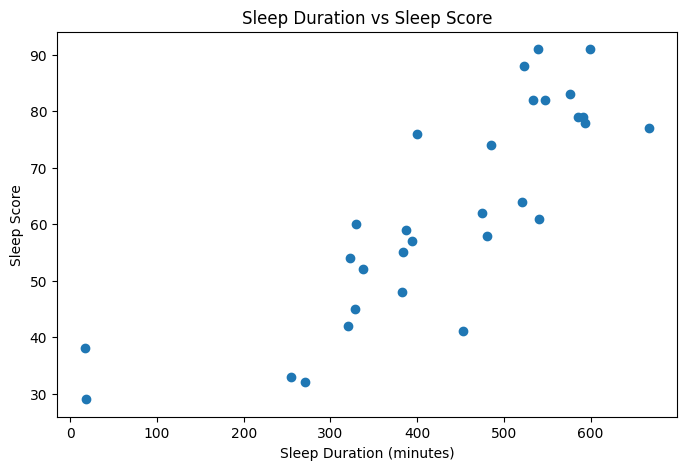

In [44]:
if "Sleep Duration" in data.columns and "Sleep Score" in data.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(data["Sleep Duration"], data["Sleep Score"])
    plt.xlabel("Sleep Duration (minutes)")
    plt.ylabel("Sleep Score")
    plt.title("Sleep Duration vs Sleep Score")
    plt.show()

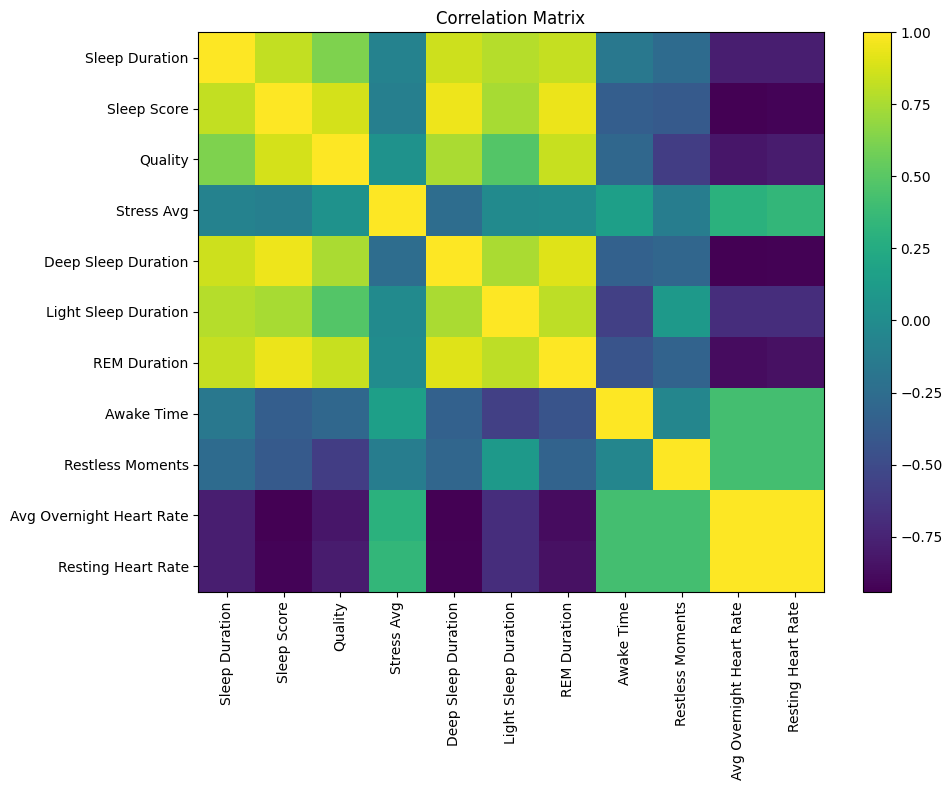

In [45]:
numeric_data = data.select_dtypes(include=[np.number])

corr = numeric_data.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [46]:
target_col = "Sleep Score"

if target_col not in data.columns:
    raise ValueError("Sleep Score column not found. Check your dataset columns.")

X = data.drop(columns=[target_col])
y = data[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature columns:", X.columns.tolist())

X shape: (30, 14)
y shape: (30,)
Feature columns: ['Sleep Duration', 'Quality', 'Stress Avg', 'Deep Sleep Duration', 'Light Sleep Duration', 'REM Duration', 'Awake Time', 'Restless Moments', 'Avg Overnight Heart Rate', 'Resting Heart Rate', 'Body Battery Change', 'Avg Respiration', 'Avg Overnight HRV', '7d Avg HRV']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 24
Testing rows: 6


In [48]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [49]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

MAE : 2.604
RMSE: 2.841
R²  : 0.969


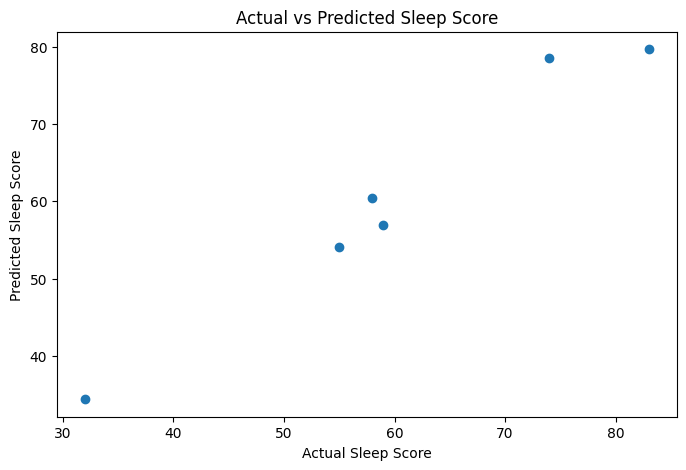

In [50]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds)
plt.xlabel("Actual Sleep Score")
plt.ylabel("Predicted Sleep Score")
plt.title("Actual vs Predicted Sleep Score")
plt.show()

                     Feature  Importance
10       Body Battery Change    0.216233
13                7d Avg HRV    0.127398
5               REM Duration    0.126962
12         Avg Overnight HRV    0.119862
3        Deep Sleep Duration    0.119645
8   Avg Overnight Heart Rate    0.078529
1                    Quality    0.077627
9         Resting Heart Rate    0.057533
0             Sleep Duration    0.037591
4       Light Sleep Duration    0.018091
7           Restless Moments    0.010712
2                 Stress Avg    0.003956
6                 Awake Time    0.003399
11           Avg Respiration    0.002461


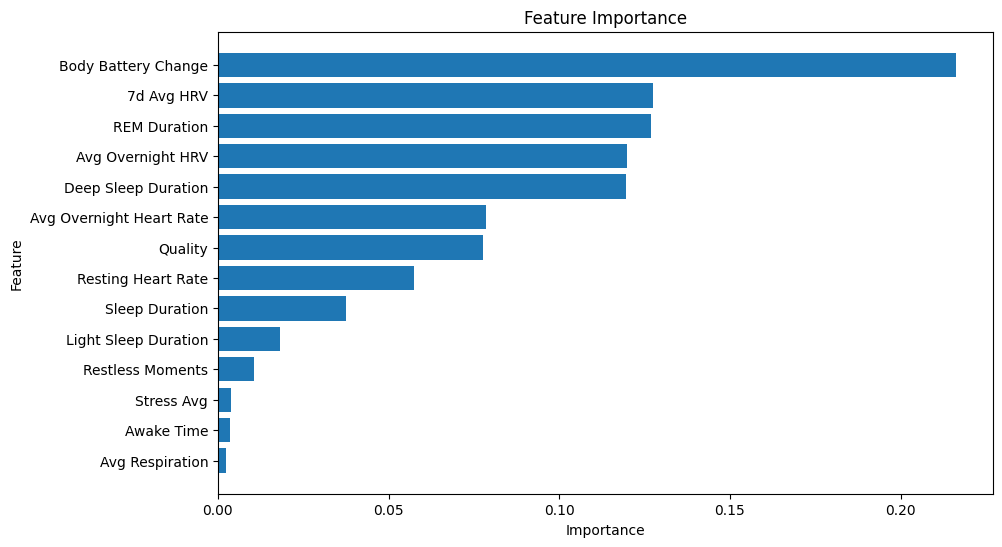

In [51]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [52]:
model_path = "/content/drive/MyDrive/sleep_score_model.pkl"
joblib.dump(model, model_path)
print("Saved trained model to:", model_path)

Saved trained model to: /content/drive/MyDrive/sleep_score_model.pkl


In [53]:
sample = X.iloc[[0]]
sample_pred = model.predict(sample)

print("Sample input:")
print(sample)

print("\nPredicted Sleep Score:", round(sample_pred[0], 2))

Sample input:
   Sleep Duration  Quality  Stress Avg  Deep Sleep Duration  \
0             382        0       20.68                   50   

   Light Sleep Duration  REM Duration  Awake Time  Restless Moments  \
0                   240            70          22                35   

   Avg Overnight Heart Rate  Resting Heart Rate Body Battery Change  \
0                        57                  52                  34   

  Avg Respiration Avg Overnight HRV 7d Avg HRV  
0            16.9                56         50  

Predicted Sleep Score: 47.98
